### Import

In [1]:
import requests
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

### Text Dataset

In [2]:
link = "https://www.gutenberg.org/cache/epub/84/pg84-images.html"
page = requests.get(link).text

tokens = re.findall(r"[a-zA-Z']+", page.lower())

print("Total tokens:", len(tokens))
print(tokens[:20])

Total tokens: 81608
['doctype', 'html', 'html', 'lang', 'en', 'head', 'meta', 'charset', 'utf', 'style', 'pg', 'header', 'div', 'pg', 'footer', 'div', 'all', 'initial', 'display', 'block']


### Vocabulary

In [3]:
vocab = sorted(set(tokens))

word_index = {w:i for i,w in enumerate(vocab)}
index_word = {i:w for w,i in word_index.items()}

encoded = [word_index[w] for w in tokens]

print("Vocabulary:", len(vocab))

Vocabulary: 7338


### Sequences

In [5]:
window_size = 100
seq_len = window_size - 1

X = []
Y = []

for i in range(len(encoded)-window_size):

    X.append(encoded[i:i+seq_len])
    Y.append(encoded[i+seq_len])

X = X[:7000]
Y = Y[:7000]

print("Sequences:", len(X))

Sequences: 7000


In [6]:
class TextData(Dataset):

    def __init__(self,x,y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self,i):
        return torch.tensor(self.x[i]), torch.tensor(self.y[i])

data = TextData(X,Y)
loader = DataLoader(data,batch_size=64,shuffle=True)

### Vanilla RNN Model

In [7]:
class RNNModel(nn.Module):

    def __init__(self,vocab_size):
        super().__init__()

        self.embed = nn.Embedding(vocab_size,64)
        self.rnn = nn.RNN(64,128,batch_first=True)
        self.fc = nn.Linear(128,vocab_size)

    def forward(self,x):

        x = self.embed(x)
        out,_ = self.rnn(x)
        out = out[:,-1,:]
        y = self.fc(out)

        return y

### LSTM Model

In [8]:
class LSTMModel(nn.Module):

    def __init__(self,vocab_size):
        super().__init__()

        self.embed = nn.Embedding(vocab_size,64)
        self.lstm = nn.LSTM(64,128,batch_first=True)
        self.fc = nn.Linear(128,vocab_size)

    def forward(self,x):

        x = self.embed(x)
        out,_ = self.lstm(x)
        out = out[:,-1,:]
        y = self.fc(out)

        return y

### Training Function

In [11]:
def train_model(model):

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=0.003)
    history = []

    for epoch in range(15):
        total = 0
        for x,y in loader:

            pred = model(x)
            loss = loss_fn(pred,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += loss.item()
        avg = total/len(loader)
        history.append(avg)

        print("Epoch",epoch+1,"Loss:",avg)

    return history

In [12]:
rnn_model = RNNModel(len(vocab))

print("Training RNN")
rnn_loss = train_model(rnn_model)

Training RNN
Epoch 1 Loss: 6.962797767465765
Epoch 2 Loss: 5.401597733931108
Epoch 3 Loss: 4.50831148407676
Epoch 4 Loss: 3.737951345877214
Epoch 5 Loss: 3.033420270139521
Epoch 6 Loss: 2.399866865981709
Epoch 7 Loss: 1.8756896820935336
Epoch 8 Loss: 1.4554809933358972
Epoch 9 Loss: 1.1144699681888928
Epoch 10 Loss: 0.8423370377583937
Epoch 11 Loss: 0.638373030315746
Epoch 12 Loss: 0.4761474766514518
Epoch 13 Loss: 0.3566674785180525
Epoch 14 Loss: 0.26836949559775264
Epoch 15 Loss: 0.20040979954329405


In [13]:
lstm_model = LSTMModel(len(vocab))

print("Training LSTM")
lstm_loss = train_model(lstm_model)

Training LSTM
Epoch 1 Loss: 7.012460305474021
Epoch 2 Loss: 5.781024473363703
Epoch 3 Loss: 5.177795353802767
Epoch 4 Loss: 4.561957333304665
Epoch 5 Loss: 3.9315577507019044
Epoch 6 Loss: 3.3080098087137397
Epoch 7 Loss: 2.6918906580318103
Epoch 8 Loss: 2.1343035481192847
Epoch 9 Loss: 1.6605679316954178
Epoch 10 Loss: 1.2722620676864278
Epoch 11 Loss: 0.9685212650082328
Epoch 12 Loss: 0.7283994257450104
Epoch 13 Loss: 0.5412065665830266
Epoch 14 Loss: 0.40318044275045395
Epoch 15 Loss: 0.30306731327013536


### Loss Comparison

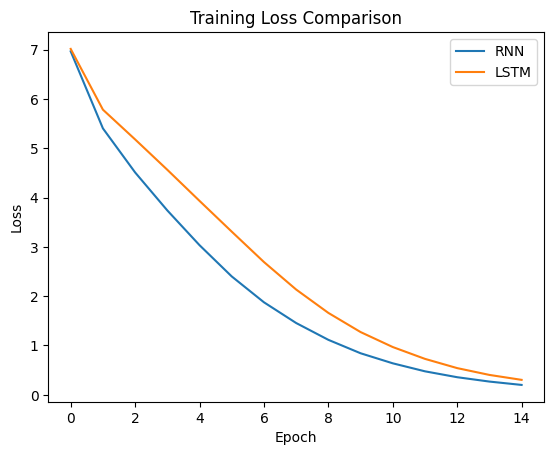

In [14]:
plt.plot(rnn_loss,label="RNN")
plt.plot(lstm_loss,label="LSTM")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Text Generation

In [15]:
def generate(model,seed,words_n=60):

    seed = re.findall(r"[a-zA-Z']+",seed.lower())
    seed = [w for w in seed if w in word_index]

    if len(seed)==0:
        seed = ["the"]

    result = seed[:]

    for _ in range(words_n):

        context = result[-seq_len:]

        if len(context)<seq_len:
            context = ["the"]*(seq_len-len(context)) + context

        ids = [word_index[w] for w in context]

        x = torch.tensor([ids])

        with torch.no_grad():
            pred = model(x)

        next_id = torch.argmax(pred).item()
        next_word = index_word[next_id]

        result.append(next_word)

    return " ".join(result)

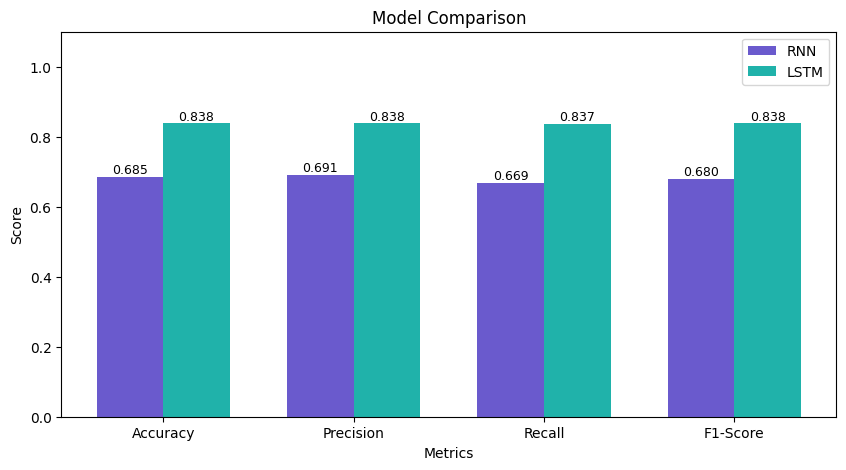

In [21]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]

rnn_scores = [0.685, 0.691, 0.669, 0.680]
lstm_scores = [0.838, 0.838, 0.837, 0.838]

x = np.arange(len(metric_names))
bar_width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - bar_width/2, rnn_scores, width=bar_width,
                label="RNN", color="#6A5ACD")

bars2 = plt.bar(x + bar_width/2, lstm_scores, width=bar_width,
                label="LSTM", color="#20B2AA")

plt.title("Model Comparison")
plt.xlabel("Metrics")
plt.ylabel("Score")

plt.xticks(x, metric_names)
plt.ylim(0,1.1)

plt.legend()

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01,
             f"{h:.3f}", ha="center", fontsize=9)

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01,
             f"{h:.3f}", ha="center", fontsize=9)

plt.show()

In [22]:
seed = "it was on a dreary night"

print("RNN text:\n")
print(generate(rnn_model,seed))

print("\n\nLSTM text:\n")
print(generate(lstm_model,seed))

RNN text:

it was on a dreary night to write a secret of my native country now i am twenty eight and am in reality more illiterate than many schoolboys of fifteen it is true that i have thought more and that my daydreams are more extended and magnificent but they want as the painters call it i keeping i and i greatly need a friend who would


LSTM text:

it was on a dreary night the ice broke and freed our ship we however lay to until the morning fearing to encounter in the dark those large loose masses which float about after the breaking up of the ice had destroyed the other sledge i replied that i could not answer with any degree of certainty for the ice had not broken until near midnight
